# Machine Learning Model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Dataset reading
#at_risk_diabetes is output(categories)

diabetes = pd.read_csv(r"C:\Users\KIIT0001\Documents\GitHub\Mini_project_ML\required_files\Diabetes_dataset_2.csv")
diabetes

,age,bmi,glucose_level,physical_activity_level,family_history,smoker,at_risk_diabetes
0,58,33.154816,71.049867,low,0,0,1
1,71,26.786882,125.964887,low,0,0,0
2,48,20.977319,61.876196,moderate,1,1,0
3,34,27.959924,137.648074,low,0,0,0
4,62,28.304175,65.879564,moderate,0,0,0
...,...,...,...,...,...,...,...
99997,71,26.504374,66.520077,moderate,0,0,0
99998,62,31.735351,105.753990,high,1,0,1
99999,61,30.627113,81.916400,high,0,1,0
100000,0,0.000000,0.000000,low,1,0,1


In [3]:
#displays the unique values only 
for i in diabetes.columns:
    print(i,':','\n',diabetes[i].unique(),'\n') 

age : 
 [58 71 48 34 62 27 40 77 38 42 30 43 72 55 59 22 41 21 63 49 57 79 52 31
 44 68 46 78 61 47 35 66 70 74 76 56 26 28 37 23 33 69 45 39 54 36 25 73
 53 29 50 67 64 60 20 24 32 51 75 65  0  1] 

bmi : 
 [33.15481565 26.78688161 20.97731911 ... 31.73535116 30.62711346
  0.        ] 

glucose_level : 
 [ 71.04986701 125.96488728  61.8761961  ... 105.75399037  81.91640046
   0.        ] 

physical_activity_level : 
 ['low' 'moderate' 'high'] 

family_history : 
 [0 1] 

smoker : 
 [0 1] 

at_risk_diabetes : 
 [1 0] 



In [4]:
# Encoding physical activity level to 0 1 2
# Label encoder can't be used as this randomly assigns the values according to alphabetical order(h,l,m)
# OrdinalEncoder requires a 2D input. So the feature is passed as a DataFrame using double brackets

from sklearn.preprocessing import OrdinalEncoder
oe = OrdinalEncoder(categories = [['low','moderate','high']]) #order is written in categories

In [5]:
# Encoding transformation applied(as 2D so [[]])
diabetes[['physical_activity_level']] = oe.fit_transform(diabetes[['physical_activity_level']]) 

In [6]:
diabetes.physical_activity_level.unique()

array([0., 1., 2.])

In [7]:
# converts our data from float type[0. ,1. , 2.] to integer
diabetes['physical_activity_level'] = diabetes['physical_activity_level'].astype(int)

In [8]:
diabetes.physical_activity_level.unique() 

array([0, 1, 2])

In [9]:
diabetes.head()

,age,bmi,glucose_level,physical_activity_level,family_history,smoker,at_risk_diabetes
0,58,33.154816,71.049867,0,0,0,1
1,71,26.786882,125.964887,0,0,0,0
2,48,20.977319,61.876196,1,1,1,0
3,34,27.959924,137.648074,0,0,0,0
4,62,28.304175,65.879564,1,0,0,0


In [10]:
diabetes['physical_activity_level'].dtype

dtype('int64')

In [11]:
# input output creation
ip = diabetes.drop('at_risk_diabetes',axis=1) #axis = 1 drops a column from input , axis = 0 drops row
op = diabetes.at_risk_diabetes # can also write diabetes[at risk diabetes]

In [12]:
# Training & Testing Split
# 80% training data , rest 20% testing data (test_siz=0.2)
# random_state used to fix the values otherwise everytime we run it takes different training and testing data 

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(ip,op,test_size=0.2,random_state=3)

In [13]:
#prints number of training and testing samples
# x_train(input) and y_train(output) are the  samples used to train the model for input and output
# x_test used for prediction of output and that is compared with original output stored in y_test

print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(80001, 6)
(80001,)
(20001, 6)
(20001,)


In [14]:
# Standard Scaler Transform

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

x_train = sc.fit_transform(x_train)
x_test = sc.fit_transform(x_test)

### Applying Logistic Regression 

In [15]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [16]:
#predict() generates predicted class labels for unseen test data using the trained model
pred = lr.predict(x_test)
pred

array([0, 0, 1, ..., 0, 0, 1], shape=(20001,))

In [17]:
y_test

79529    1
53876    0
9777     0
6167     1
22020    1
        ..
31155    0
25374    0
44141    0
45383    0
73177    0
Name: at_risk_diabetes, Length: 20001, dtype: int64

#### Accuracy using Confusion Matrix

In [18]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

acc = accuracy_score(pred,y_test)
re = recall_score(pred,y_test)
pr = precision_score(pred,y_test)
f1 = f1_score(pred,y_test)

print('Accuracy:',acc)
print('Recall:',re)
print('Precision:',pr)
print('F1-Score:',f1)

Accuracy: 0.855757212139393
Recall: 0.7161203109158499
Precision: 0.5088856868395774
F1-Score: 0.5949740277972765


In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
conf_mat = confusion_matrix(pred,y_test)
conf_mat

array([[14997,  2045],
       [  840,  2119]])

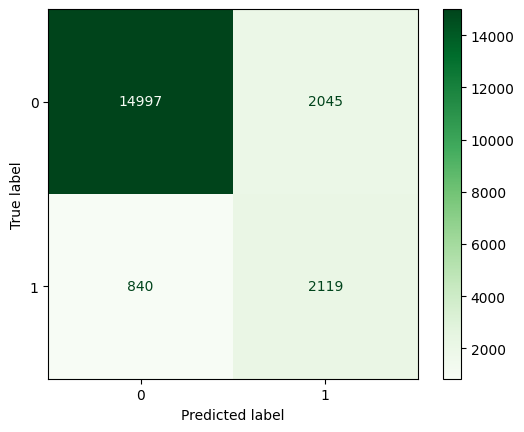

In [20]:
cmd = ConfusionMatrixDisplay(conf_mat)
cmd.plot(cmap = 'Greens')
plt.show()

### Applying SVM (Support Vector Classfier)

In [21]:
# kernel rbf(radial basis function) creates curved decision boundary for better fit of non linear cols(BMI,glucose)
# gamma controls influence of each data point(0.01 is low so smooth and wide decision boundary), less sensitive to noise
# C controls penalty for mis-classification (1000 is high so less chance of errors and tries to classify all data point correct)

from sklearn.svm import SVC
svc = SVC(kernel='rbf',gamma=0.01,C=1000)
svc.fit(x_train,y_train)

,C,1000
,kernel,'rbf'
,degree,3
,gamma,0.01
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [22]:
pred1 = svc.predict(x_test)
pred1

array([1, 0, 0, ..., 0, 0, 0], shape=(20001,))

In [23]:
y_test

79529    1
53876    0
9777     0
6167     1
22020    1
        ..
31155    0
25374    0
44141    0
45383    0
73177    0
Name: at_risk_diabetes, Length: 20001, dtype: int64

In [39]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

acc2 = accuracy_score(pred1, y_test)
re = recall_score(pred1, y_test)
pr = precision_score(pred1, y_test)
f1 = f1_score(pred1, y_test)

print('Accuracy:',acc2)
print('Recall:',re)
print('Precision:',pr)
print('F1-Score:',f1)

Accuracy: 0.7071646417679116
Recall: 0.21855397821063058
Precision: 0.15944123314065511
F1-Score: 0.1843754351761593


# Applying Random Forest

In [25]:
from sklearn.ensemble import RandomForestClassifier

In [26]:
diabetes

,age,bmi,glucose_level,physical_activity_level,family_history,smoker,at_risk_diabetes
0,58,33.154816,71.049867,0,0,0,1
1,71,26.786882,125.964887,0,0,0,0
2,48,20.977319,61.876196,1,1,1,0
3,34,27.959924,137.648074,0,0,0,0
4,62,28.304175,65.879564,1,0,0,0
...,...,...,...,...,...,...,...
99997,71,26.504374,66.520077,1,0,0,0
99998,62,31.735351,105.753990,2,1,0,1
99999,61,30.627113,81.916400,2,0,1,0
100000,0,0.000000,0.000000,0,1,0,1


In [27]:
X = diabetes.drop("at_risk_diabetes", axis=1)
y = diabetes["at_risk_diabetes"]

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
rf = RandomForestClassifier(n_estimators = 100,random_state=42)
rf.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [30]:
pred2 = rf.predict(X_test)
pred2

array([0, 1, 0, ..., 0, 0, 0], shape=(20001,))

In [31]:
print('Accuracy:',accuracy_score(y_test,pred2))
print('Recall:',recall_score(y_test,pred2))
print('Precision:',precision_score(y_test,pred2))
print('F1 Score:',f1_score(y_test,pred2))

Accuracy: 0.911954402279886
Recall: 0.7514450867052023
Precision: 0.8106001558846454
F1 Score: 0.7799025121859767


In [32]:
confusion_mat = confusion_matrix(y_test,pred2)
confusion_mat

array([[15120,   729],
       [ 1032,  3120]])

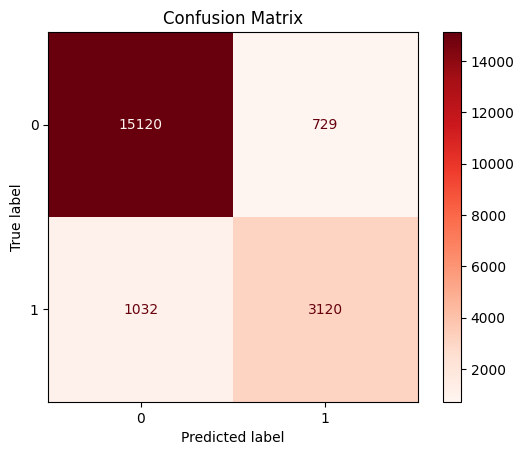

In [33]:
cmd = ConfusionMatrixDisplay(confusion_mat)
cmd.plot(cmap = 'Reds')
plt.title('Confusion Matrix')
plt.show()

In [34]:
from sklearn.metrics import classification_report
print('Classification Report:',classification_report(y_test,pred2))

Classification Report:               precision    recall  f1-score   support

           0       0.94      0.95      0.94     15849
           1       0.81      0.75      0.78      4152

    accuracy                           0.91     20001
   macro avg       0.87      0.85      0.86     20001
weighted avg       0.91      0.91      0.91     20001



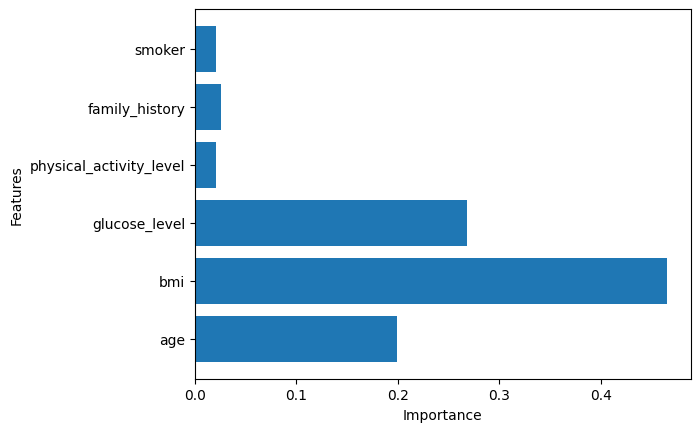

In [35]:
#It shows the importance of each attribute in finding the output

import matplotlib.pyplot as plt

feature_importance = rf.feature_importances_
features = X.columns

plt.barh(features, feature_importance)
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

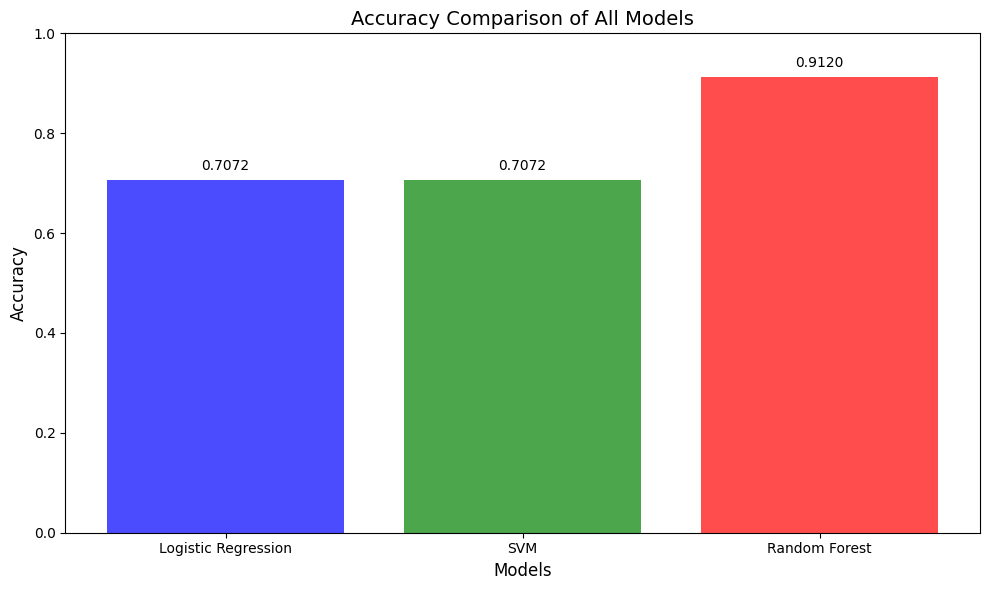

In [40]:
# Capture Random Forest accuracy
acc_rf = accuracy_score(y_test, pred2)

# Create histogram of all model accuracies
models = ['Logistic Regression', 'SVM', 'Random Forest']
accuracies = [acc, acc2, acc_rf]

plt.figure(figsize=(10, 6))
plt.bar(models, accuracies, color=['blue', 'green', 'red'], alpha=0.7)
plt.xlabel('Models', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Accuracy Comparison of All Models', fontsize=14)
plt.ylim([0, 1])
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.02, f'{v:.4f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()